In [1]:
!pip install kagglehub pandasql seaborn plotly -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd


path = r"D:\Flight_Booking.csv"

df = pd.read_csv(path)
print("Shape:", df.shape)
print("\nКолонки:", df.columns.tolist())
print("\nПервые 2 строки:")
print(df.head(2))

Shape: (300153, 12)

Колонки: ['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price']

Первые 2 строки:
   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   

  arrival_time destination_city    class  duration  days_left  price  
0        Night           Mumbai  Economy      2.17          1   5953  
1      Morning           Mumbai  Economy      2.33          1   5953  


In [5]:

flights = df[['flight', 'airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time', 'duration', 'stops']].drop_duplicates().reset_index(drop=True)
flights['flight_id'] = range(1, len(flights)+1)

bookings = df[['flight', 'class', 'days_left', 'price']].copy()
bookings = bookings.merge(flights[['flight', 'flight_id']], on='flight', how='left')
bookings['booking_id'] = range(1, len(bookings)+1)
bookings = bookings[['booking_id', 'flight_id', 'class', 'days_left', 'price']]


flights.to_csv('flights.csv', index=False)
bookings.to_csv('bookings.csv', index=False)
df.to_csv('full_data.csv', index=False)

print("Таблицы созданы:")
print(f"flights: {flights.shape} — справочник рейсов")
print(f"bookings: {bookings.shape} — бронирования")
print(f"full_data: {df.shape} — полная таблица")

Таблицы созданы:
flights: (12955, 9) — справочник рейсов
bookings: (9057222, 5) — бронирования
full_data: (300153, 12) — полная таблица


In [6]:
!pip install pandasql -q
from pandasql import sqldf


query = """
SELECT 
    b.booking_id,
    f.airline,
    f.source_city,
    f.destination_city,
    b.class,
    b.price,
    b.days_left
FROM bookings b
JOIN flights f ON b.flight_id = f.flight_id
LIMIT 10
"""

result = sqldf(query)
print(result)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   booking_id   airline source_city destination_city    class  price  \
0           1  SpiceJet       Delhi           Mumbai  Economy   5953   
1           2  SpiceJet       Delhi           Mumbai  Economy   5953   
2           3  SpiceJet       Delhi          Chennai  Economy   5953   
3           4  SpiceJet       Delhi          Chennai  Economy   5953   
4           5  SpiceJet       Delhi          Chennai  Economy   5953   
5           6  SpiceJet       Delhi          Chennai  Economy   5953   
6           7  SpiceJet       Delhi           Mumbai  Economy   5953   
7           8  SpiceJet       Delhi          Chennai  Economy   5953   
8           9  SpiceJet       Delhi          Chennai  Economy   5953   
9          10  SpiceJet       Delhi          Chennai  Economy   5953   

   days_left  
0          1  
1          1  
2          1  
3          1  
4          1  
5          1  
6          1  
7          1  
8          1  
9          1  


In [8]:
import pandas as pd
import numpy as np
from pandasql import sqldf


df = pd.read_csv(r"D:\Flight_Booking.csv")


full_data = df.copy()
flights = df[['flight', 'airline', 'source_city', 'destination_city', 'departure_time', 'arrival_time', 'duration', 'stops']].drop_duplicates().reset_index(drop=True)
flights['flight_id'] = range(1, len(flights)+1)

bookings = df[['flight', 'class', 'days_left', 'price']].copy()
bookings = bookings.merge(flights[['flight', 'flight_id']], on='flight', how='left')
bookings['booking_id'] = range(1, len(bookings)+1)
bookings = bookings[['booking_id', 'flight_id', 'class', 'days_left', 'price']]

print("✓ full_data:", full_data.shape)
print("✓ flights:", flights.shape)
print("✓ bookings:", bookings.shape)

✓ full_data: (300153, 12)
✓ flights: (12955, 9)
✓ bookings: (9057222, 5)


In [9]:
query1 = """
SELECT 
    airline,
    class,
    ROUND(AVG(price), 0) AS avg_price,
    RANK() OVER (PARTITION BY class ORDER BY AVG(price) DESC) AS price_rank,
    ROUND(AVG(price) - AVG(AVG(price)) OVER (PARTITION BY class), 0) AS diff_from_class_avg
FROM full_data
GROUP BY airline, class
ORDER BY class, price_rank
"""

result1 = sqldf(query1)
print("Ранг авиакомпаний по средней цене внутри класса:")
print(result1.head(20))

Ранг авиакомпаний по средней цене внутри класса:
     airline     class  avg_price  price_rank  diff_from_class_avg
0    Vistara  Business    55477.0           1               4173.0
1  Air_India  Business    47131.0           2              -4173.0
2    Vistara   Economy     7807.0           1               1746.0
3  Air_India   Economy     7314.0           2               1252.0
4   SpiceJet   Economy     6179.0           3                118.0
5   GO_FIRST   Economy     5652.0           4               -409.0
6     Indigo   Economy     5324.0           5               -737.0
7    AirAsia   Economy     4091.0           6              -1970.0


In [10]:
query2 = """
WITH daily_revenue AS (
    SELECT 
        days_left,
        SUM(price) AS revenue
    FROM full_data
    GROUP BY days_left
)
SELECT 
    days_left,
    revenue,
    SUM(revenue) OVER (ORDER BY days_left) AS cumulative_revenue,
    ROUND(revenue * 100.0 / SUM(revenue) OVER (), 2) AS pct_of_total
FROM daily_revenue
ORDER BY days_left
"""

result2 = sqldf(query2)
print("Кумулятивная выручка по дням до вылета:")
print(result2.head(15))

Кумулятивная выручка по дням до вылета:
    days_left    revenue  cumulative_revenue  pct_of_total
0           1   41607528            41607528          0.66
1           2  121630693           163238221          1.94
2           3  123090403           286328624          1.96
3           4  130635808           416964432          2.08
4           5  143857338           560821770          2.29
5           6  142676275           703498045          2.28
6           7  145930459           849428504          2.33
7           8  143574563           993003067          2.29
8           9  145739184          1138742251          2.32
9          10  148884953          1287627204          2.37
10         11  147531040          1435158244          2.35
11         12  143609531          1578767775          2.29
12         13  144082862          1722850637          2.30
13         14  143982637          1866833274          2.30
14         15  139179109          2006012383          2.22


In [11]:
query3 = """
WITH route_stats AS (
    SELECT 
        source_city,
        destination_city,
        class,
        COUNT(*) AS bookings,
        ROUND(AVG(price), 0) AS avg_price
    FROM full_data
    GROUP BY source_city, destination_city, class
),
route_totals AS (
    SELECT 
        source_city,
        destination_city,
        SUM(bookings) AS total_bookings
    FROM route_stats
    GROUP BY source_city, destination_city
)
SELECT 
    rs.source_city,
    rs.destination_city,
    rs.class,
    rs.bookings,
    rs.avg_price,
    ROUND(rs.bookings * 100.0 / rt.total_bookings, 1) AS class_share_pct,
    RANK() OVER (PARTITION BY rs.source_city, rs.destination_city ORDER BY rs.bookings DESC) AS rank
FROM route_stats rs
JOIN route_totals rt 
    ON rs.source_city = rt.source_city 
    AND rs.destination_city = rt.destination_city
ORDER BY rt.total_bookings DESC, rs.source_city, rs.destination_city, rs.bookings DESC
LIMIT 20
"""

result3 = sqldf(query3)
print("Распределение классов по направлениям:")
print(result3)

Распределение классов по направлениям:
   source_city destination_city     class  bookings  avg_price  \
0        Delhi           Mumbai   Economy      9982     6060.0   
1        Delhi           Mumbai  Business      5307    44364.0   
2       Mumbai            Delhi   Economy      9801     5889.0   
3       Mumbai            Delhi  Business      5008    43846.0   
4        Delhi        Bangalore   Economy     10144     6176.0   
5        Delhi        Bangalore  Business      3868    48576.0   
6    Bangalore            Delhi   Economy      9959     6125.0   
7    Bangalore            Delhi  Business      3797    48144.0   
8    Bangalore           Mumbai   Economy      8743     6381.0   
9    Bangalore           Mumbai  Business      4196    58025.0   
10      Mumbai        Bangalore   Economy      8706     6433.0   
11      Mumbai        Bangalore  Business      4179    57971.0   
12      Mumbai          Kolkata   Economy      8774     7228.0   
13      Mumbai          Kolkata  Busi

In [12]:
query4 = """
WITH daily_avg AS (
    SELECT 
        days_left,
        ROUND(AVG(price), 0) AS avg_price
    FROM full_data
    GROUP BY days_left
)
SELECT 
    days_left,
    avg_price,
    ROUND(AVG(avg_price) OVER (ORDER BY days_left ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING), 0) AS smoothed_avg_7d,
    avg_price - LAG(avg_price, 1) OVER (ORDER BY days_left) AS day_over_day_change
FROM daily_avg
ORDER BY days_left
"""

result4 = sqldf(query4)
print("Динамика цен с 7-дневным сглаживанием:")
print(result4.head(15))

Динамика цен с 7-дневным сглаживанием:
    days_left  avg_price  smoothed_avg_7d  day_over_day_change
0           1    21592.0          26628.0                  NaN
1           2    30211.0          26638.0               8619.0
2           3    28976.0          26341.0              -1235.0
3           4    25731.0          26233.0              -3245.0
4           5    26680.0          26705.0                949.0
5           6    24856.0          26065.0              -1824.0
6           7    25588.0          25579.0                732.0
7           8    24896.0          25187.0               -692.0
8           9    25726.0          24591.0                830.0
9          10    25573.0          24254.0               -153.0
10         11    22991.0          23838.0              -2582.0
11         12    22506.0          23418.0               -485.0
12         13    22499.0          22672.0                 -7.0
13         14    22678.0          21931.0                179.0
14         15   

In [13]:
query5 = """
WITH route_airline AS (
    SELECT 
        source_city || ' → ' || destination_city AS route,
        airline,
        COUNT(*) AS flights_count,
        ROUND(AVG(price), 0) AS avg_price,
        ROW_NUMBER() OVER (PARTITION BY source_city, destination_city ORDER BY COUNT(*) DESC) AS rank
    FROM full_data
    GROUP BY source_city, destination_city, airline
)
SELECT route, airline, flights_count, avg_price, rank
FROM route_airline
WHERE rank <= 3
ORDER BY route, rank
LIMIT 30
"""

result5 = sqldf(query5)
print("Топ-3 авиакомпании по каждому направлению:")
print(result5)

Топ-3 авиакомпании по каждому направлению:
                    route    airline  flights_count  avg_price  rank
0     Bangalore → Chennai    Vistara           3953    26137.0     1
1     Bangalore → Chennai  Air_India           1610    26766.0     2
2     Bangalore → Chennai   GO_FIRST            369     5352.0     3
3       Bangalore → Delhi    Vistara           5423    28849.0     1
4       Bangalore → Delhi  Air_India           2633    20699.0     2
5       Bangalore → Delhi     Indigo           1961     6273.0     3
6   Bangalore → Hyderabad    Vistara           4686    27775.0     1
7   Bangalore → Hyderabad  Air_India           2228    23396.0     2
8   Bangalore → Hyderabad     Indigo           1318     3221.0     3
9     Bangalore → Kolkata    Vistara           4370    35747.0     1
10    Bangalore → Kolkata  Air_India           2026    29106.0     2
11    Bangalore → Kolkata     Indigo           1637     6230.0     3
12     Bangalore → Mumbai    Vistara           5380    34961

In [14]:
import numpy as np


print("=" * 60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ: ЦЕНА БИЛЕТОВ")
print("=" * 60)

for cls in df['class'].unique():
    prices = df[df['class'] == cls]['price']
    print(f"\n--- Класс: {cls} ---")
    print(f"  Среднее (mean):     {prices.mean():,.0f} ₽")
    print(f"  Медиана (median):   {prices.median():,.0f} ₽")
    print(f"  Мода (mode):        {prices.mode().values[0]:,.0f} ₽")
    print(f"  Стандартное откл.:  {prices.std():,.0f} ₽")
    print(f"  IQR (межкварт.размах): {prices.quantile(0.75) - prices.quantile(0.25):,.0f} ₽")
    print(f"  Коэффициент вариации: {prices.std() / prices.mean() * 100:.1f}%")
    print(f"  Мин: {prices.min():,} | Q1: {prices.quantile(0.25):,.0f} | Q3: {prices.quantile(0.75):,.0f} | Макс: {prices.max():,}")

ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ: ЦЕНА БИЛЕТОВ

--- Класс: Economy ---
  Среднее (mean):     6,572 ₽
  Медиана (median):   5,772 ₽
  Мода (mode):        2,339 ₽
  Стандартное откл.:  3,744 ₽
  IQR (межкварт.размах): 3,573 ₽
  Коэффициент вариации: 57.0%
  Мин: 1,105 | Q1: 4,173 | Q3: 7,746 | Макс: 42,349

--- Класс: Business ---
  Среднее (mean):     52,540 ₽
  Медиана (median):   53,164 ₽
  Мода (mode):        54,608 ₽
  Стандартное откл.:  12,969 ₽
  IQR (межкварт.размах): 15,211 ₽
  Коэффициент вариации: 24.7%
  Мин: 12,000 | Q1: 45,185 | Q3: 60,396 | Макс: 123,071


In [15]:
print("\n" + "=" * 60)
print("АНАЛИЗ ПРОЦЕНТИЛЕЙ ЦЕН")
print("=" * 60)

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = np.percentile(df['price'], p)
    print(f"  {p}-й процентиль: {value:,.0f} ₽")


top10_threshold = np.percentile(df['price'], 90)
top10_revenue = df[df['price'] >= top10_threshold]['price'].sum()
total_revenue = df['price'].sum()
print(f"\n  Топ-10% дорогих билетов приносят: {top10_revenue/total_revenue*100:.1f}% выручки")


АНАЛИЗ ПРОЦЕНТИЛЕЙ ЦЕН
  1-й процентиль: 1,776 ₽
  5-й процентиль: 2,436 ₽
  10-й процентиль: 3,389 ₽
  25-й процентиль: 4,783 ₽
  50-й процентиль: 7,425 ₽
  75-й процентиль: 42,521 ₽
  90-й процентиль: 57,920 ₽
  95-й процентиль: 63,277 ₽
  99-й процентиль: 76,736 ₽

  Топ-10% дорогих билетов приносят: 32.0% выручки


In [16]:
print("\n" + "=" * 60)
print("СТАТИСТИКА: ДНИ ДО ВЫЛЕТА")
print("=" * 60)

days = df['days_left']
print(f"  Среднее: {days.mean():.1f} дней")
print(f"  Медиана: {days.median():.0f} дней")
print(f"  Стандартное откл.: {days.std():.1f} дней")
print(f"  Большинство билетов покупают за: {days.mode().values[0]} дней")


print(f"\n  P10: {np.percentile(days, 10):.0f} дн | P25: {np.percentile(days, 25):.0f} дн | P75: {np.percentile(days, 75):.0f} дн | P90: {np.percentile(days, 90):.0f} дн")


СТАТИСТИКА: ДНИ ДО ВЫЛЕТА
  Среднее: 26.0 дней
  Медиана: 26 дней
  Стандартное откл.: 13.6 дней
  Большинство билетов покупают за: 25 дней

  P10: 7 дн | P25: 15 дн | P75: 38 дн | P90: 45 дн


In [17]:
from scipy import stats

print("\n" + "=" * 60)
print("95% ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ СРЕДНЕЙ ЦЕНЫ")
print("=" * 60)

n = len(df['price'])
mean = df['price'].mean()
std_err = df['price'].std() / np.sqrt(n)
ci = stats.norm.interval(0.95, loc=mean, scale=std_err)

print(f"  Размер выборки: {n:,}")
print(f"  Средняя цена: {mean:,.0f} ₽")
print(f"  Стандартная ошибка: {std_err:,.0f} ₽")
print(f"  95% ДИ: [{ci[0]:,.0f} ; {ci[1]:,.0f}] ₽")
print(f"  Интерпретация: с вероятностью 95% средняя цена авиабилета\n  в генеральной совокупности находится в этом интервале")


95% ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ СРЕДНЕЙ ЦЕНЫ
  Размер выборки: 300,153
  Средняя цена: 20,890 ₽
  Стандартная ошибка: 41 ₽
  95% ДИ: [20,808 ; 20,971] ₽
  Интерпретация: с вероятностью 95% средняя цена авиабилета
  в генеральной совокупности находится в этом интервале


BI-ДАШБОРД: АНАЛИЗ РЫНКА АВИАБИЛЕТОВ


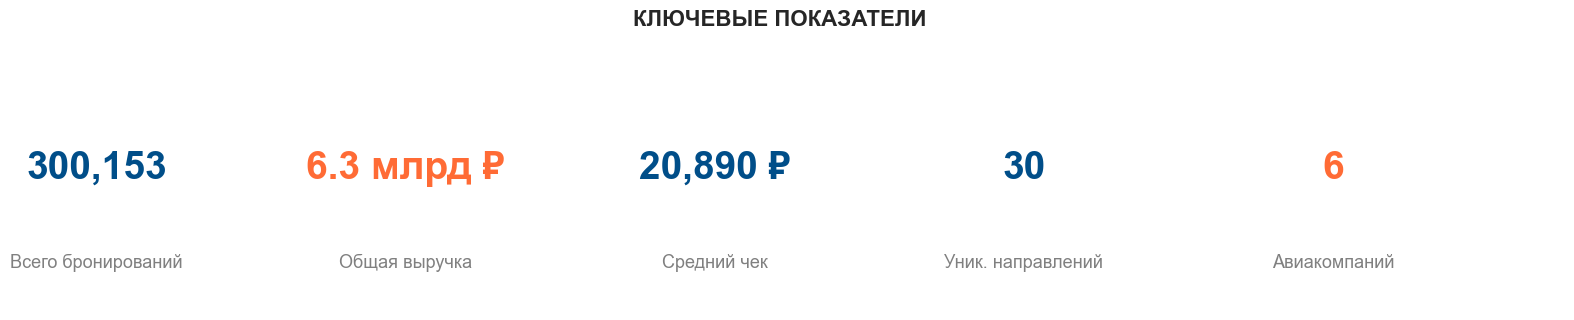

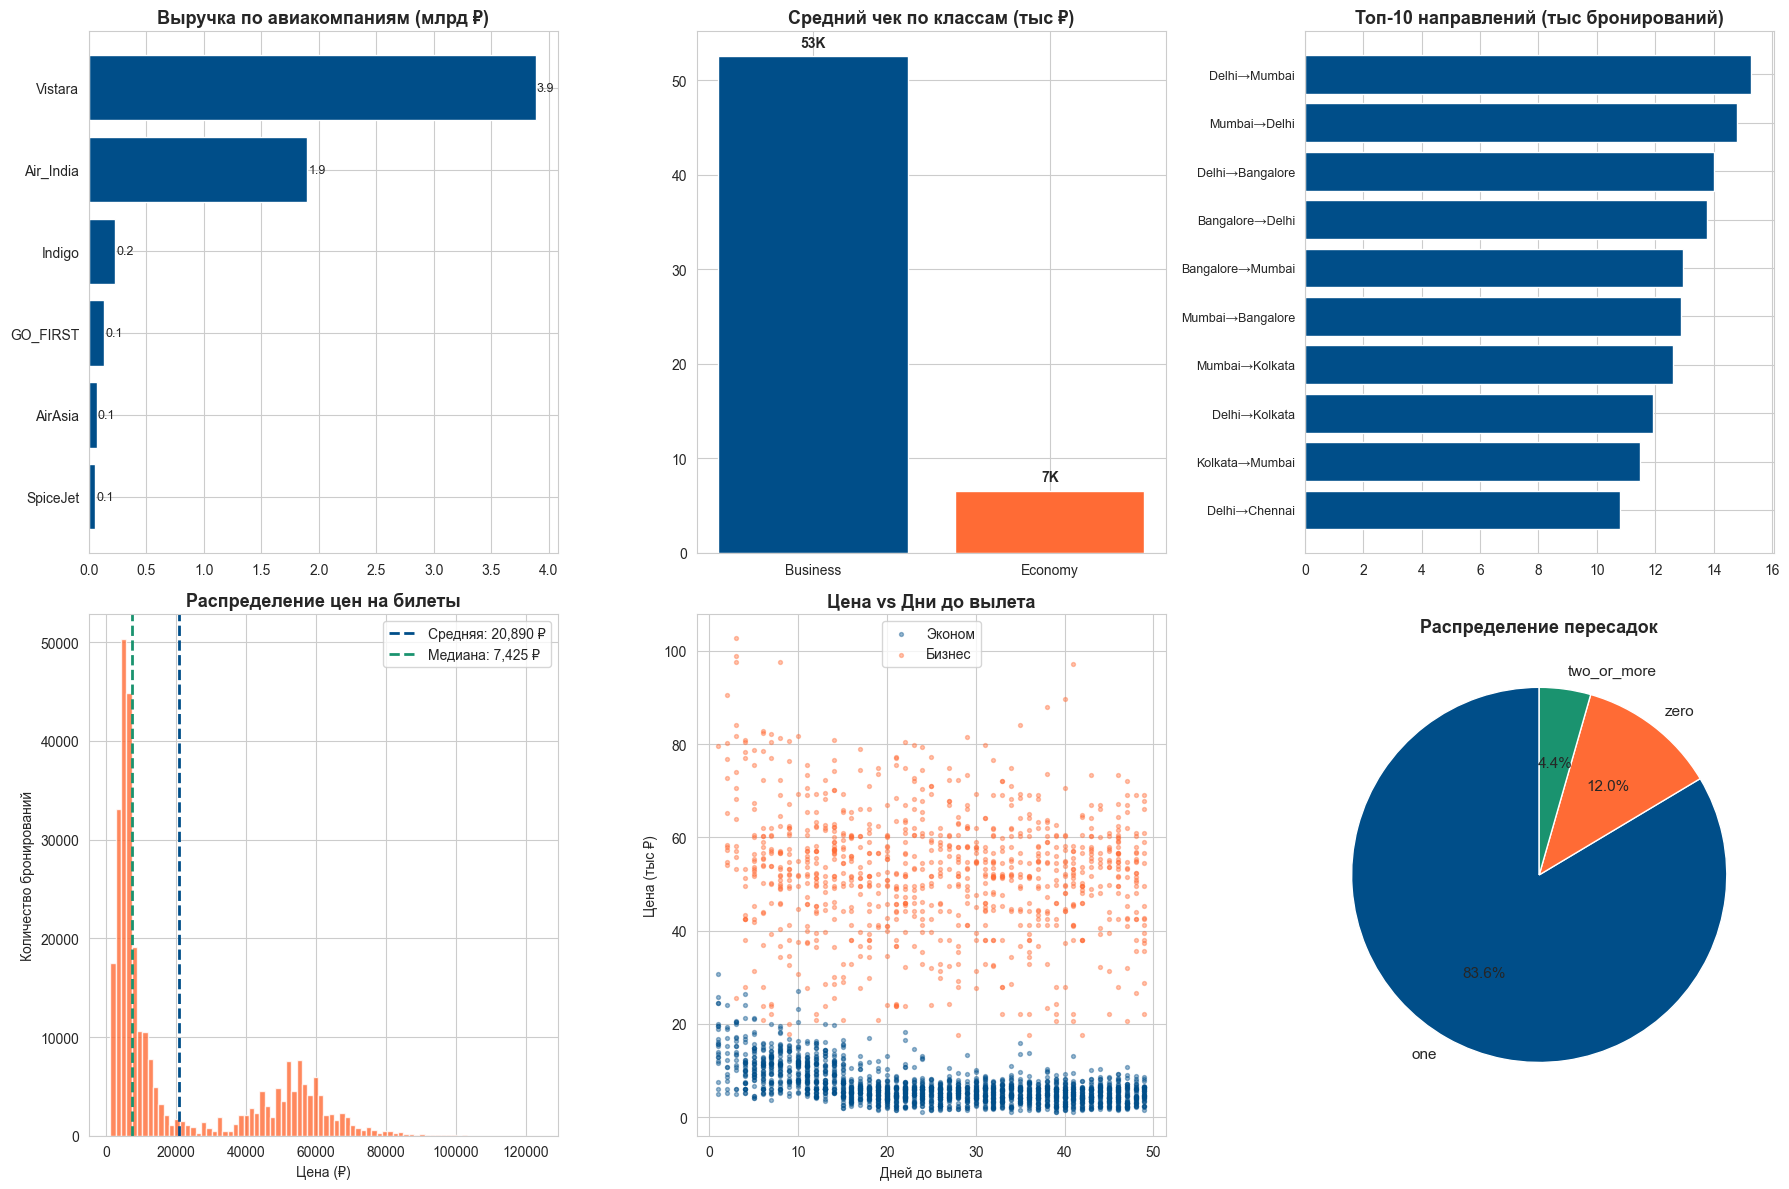

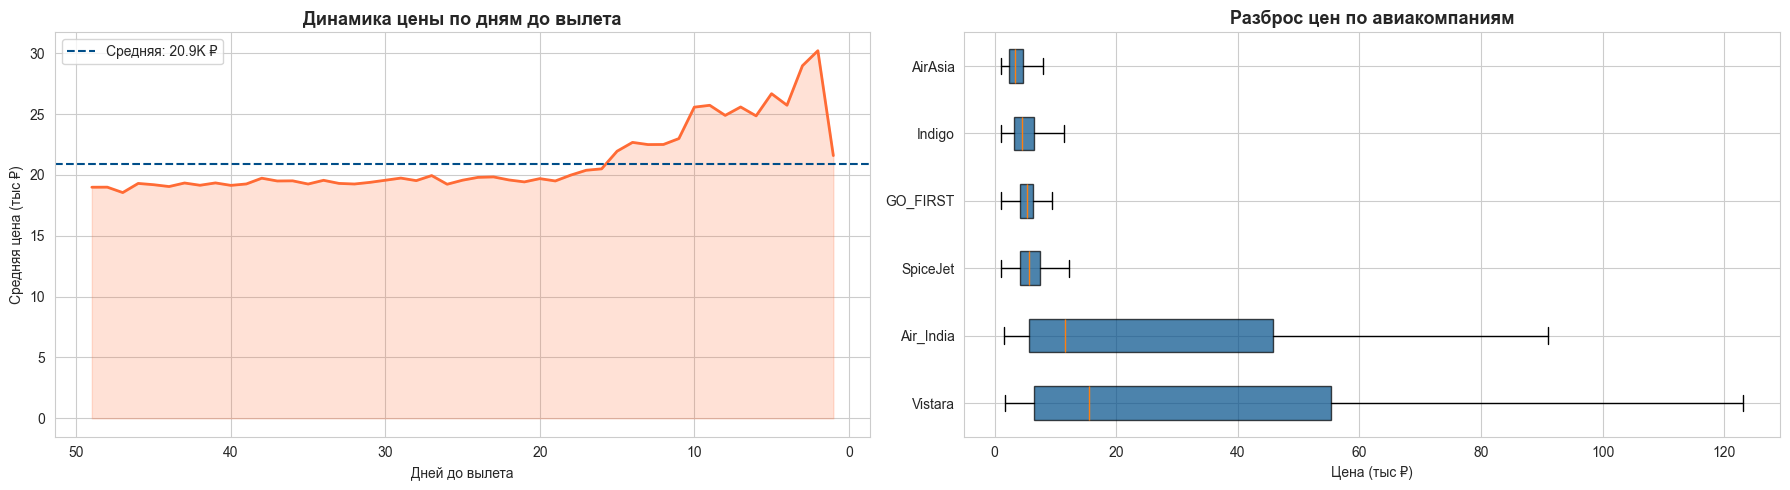

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)


aviasales_orange = '#FF6B35'
aviasales_blue = '#004E89'
aviasales_green = '#1A936F'


print("BI-ДАШБОРД: АНАЛИЗ РЫНКА АВИАБИЛЕТОВ")



total_bookings = len(df)
total_revenue = df['price'].sum()
avg_price = df['price'].mean()
routes_count = df.groupby(['source_city', 'destination_city']).ngroups
airlines_count = df['airline'].nunique()

fig, ax = plt.subplots(1, 1, figsize=(16, 3))
ax.axis('off')

kpi_data = [
    ('Всего бронирований', f'{total_bookings:,}', aviasales_blue),
    ('Общая выручка', f'{total_revenue/1e9:.1f} млрд ₽', aviasales_orange),
    ('Средний чек', f'{avg_price:,.0f} ₽', aviasales_blue),
    ('Уник. направлений', f'{routes_count}', aviasales_blue),
    ('Авиакомпаний', f'{airlines_count}', aviasales_orange)
]

for i, (title, value, color) in enumerate(kpi_data):
    ax.text(i * 0.2 + 0.05, 0.6, value, fontsize=28, fontweight='bold', color=color,
            ha='center', va='center', transform=ax.transAxes)
    ax.text(i * 0.2 + 0.05, 0.2, title, fontsize=13, color='gray',
            ha='center', va='center', transform=ax.transAxes)

plt.suptitle('КЛЮЧЕВЫЕ ПОКАЗАТЕЛИ', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Выручка по авиакомпаниям
airline_revenue = df.groupby('airline')['price'].sum().sort_values(ascending=True)
axes[0, 0].barh(airline_revenue.index, airline_revenue.values / 1e9, color=aviasales_blue)
axes[0, 0].set_title('Выручка по авиакомпаниям (млрд ₽)', fontsize=13, fontweight='bold')
for i, v in enumerate(airline_revenue.values):
    axes[0, 0].text(v/1e9 + 0.01, i, f'{v/1e9:.1f}', va='center', fontsize=9)

# 2. Средняя цена по классам
class_price = df.groupby('class')['price'].mean()
bars = axes[0, 1].bar(class_price.index, class_price.values / 1000, 
                      color=[aviasales_blue, aviasales_orange])
axes[0, 1].set_title('Средний чек по классам (тыс ₽)', fontsize=13, fontweight='bold')
for bar, v in zip(bars, class_price.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{v/1000:.0f}K', ha='center', fontweight='bold')

# 3. Топ-10 направлений
routes_count = df.groupby(['source_city', 'destination_city']).size().sort_values(ascending=False).head(10)
routes_labels = [f'{s}→{d}' for s, d in routes_count.index]
axes[0, 2].barh(range(10), routes_count.values[::-1] / 1000, color=aviasales_blue)
axes[0, 2].set_yticks(range(10))
axes[0, 2].set_yticklabels(routes_labels[::-1], fontsize=9)
axes[0, 2].set_title('Топ-10 направлений (тыс бронирований)', fontsize=13, fontweight='bold')

# 4. Распределение цен
axes[1, 0].hist(df['price'], bins=80, color=aviasales_orange, alpha=0.8, edgecolor='white')
axes[1, 0].axvline(df['price'].mean(), color=aviasales_blue, linestyle='--', linewidth=2, 
                   label=f'Средняя: {avg_price:,.0f} ₽')
axes[1, 0].axvline(df['price'].median(), color=aviasales_green, linestyle='--', linewidth=2, 
                   label=f'Медиана: {df["price"].median():,.0f} ₽')
axes[1, 0].legend()
axes[1, 0].set_title('Распределение цен на билеты', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Цена (₽)')
axes[1, 0].set_ylabel('Количество бронирований')

# 5. Цена vs Дни до вылета
sample_df = df.sample(3000, random_state=42)
for cls, color, label in [('Economy', aviasales_blue, 'Эконом'), ('Business', aviasales_orange, 'Бизнес')]:
    subset = sample_df[sample_df['class'] == cls]
    axes[1, 1].scatter(subset['days_left'], subset['price'] / 1000, 
                       c=color, label=label, alpha=0.4, s=8)
axes[1, 1].set_xlabel('Дней до вылета')
axes[1, 1].set_ylabel('Цена (тыс ₽)')
axes[1, 1].legend()
axes[1, 1].set_title('Цена vs Дни до вылета', fontsize=13, fontweight='bold')

# 6. Количество пересадок
stops_count = df['stops'].value_counts()
colors_pie = [aviasales_blue, aviasales_orange, aviasales_green]
axes[1, 2].pie(stops_count.values, labels=stops_count.index, autopct='%1.1f%%', 
               colors=colors_pie[:len(stops_count)], startangle=90,
               textprops={'fontsize': 11})
axes[1, 2].set_title('Распределение пересадок', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

daily_price = df.groupby('days_left')['price'].mean()
axes[0].plot(daily_price.index, daily_price.values / 1000, 
             color=aviasales_orange, linewidth=2)
axes[0].fill_between(daily_price.index, daily_price.values / 1000, 
                      alpha=0.2, color=aviasales_orange)
axes[0].axhline(y=df['price'].mean() / 1000, color=aviasales_blue, 
                linestyle='--', linewidth=1.5, label=f'Средняя: {avg_price/1000:.1f}K ₽')
axes[0].set_xlabel('Дней до вылета')
axes[0].set_ylabel('Средняя цена (тыс ₽)')
axes[0].set_title('Динамика цены по дням до вылета', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].invert_xaxis()

airline_order = df.groupby('airline')['price'].median().sort_values(ascending=False).index
bp = axes[1].boxplot([df[df['airline'] == a]['price'] / 1000 for a in airline_order], 
                      labels=airline_order, patch_artist=True, vert=False,
                      showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(aviasales_blue)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Цена (тыс ₽)')
axes[1].set_title('Разброс цен по авиакомпаниям', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()



In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\Flight_Booking.csv")

df = df.drop(columns=['Unnamed: 0'], errors='ignore')

if 'user_id' not in df.columns:
    np.random.seed(42)
    df['user_id'] = np.random.randint(1, 50001, len(df))

print(f"✓ Данные загружены: {df.shape[0]:,} строк, {df.shape[1]} столбцов")
print(f"✓ Колонки: {df.columns.tolist()}")

✓ Данные загружены: 300,153 строк, 12 столбцов
✓ Колонки: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price', 'user_id']


In [4]:

print("БИЗНЕС-ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ AVIASALES")


top_routes = df.groupby(['source_city', 'destination_city']).size().sort_values(ascending=False)
top_route_name = f"{top_routes.index[0][0]} → {top_routes.index[0][1]}"
top_route_share = top_routes.iloc[0] / len(df) * 100

airline_revenue = df.groupby('airline')['price'].sum()
top_airline = airline_revenue.idxmax()
top2_airlines_share = (airline_revenue.nlargest(2).sum() / airline_revenue.sum()) * 100

economy_avg = df[df['class'] == 'Economy']['price'].mean()
business_avg = df[df['class'] == 'Business']['price'].mean()

early_bookings_share = len(df[df['days_left'] > 30]) / len(df) * 100
last_minute_share = len(df[df['days_left'] <= 3]) / len(df) * 100
median_days = df['days_left'].median()

direct_share = len(df[df['stops'] == 'zero']) / len(df) * 100

top10_threshold = np.percentile(df['price'], 90)
top10_revenue_share = df[df['price'] >= top10_threshold]['price'].sum() / df['price'].sum() * 100


import datetime
np.random.seed(42)
df['user_id'] = np.random.randint(1, 50001, len(df))
reference_date = pd.Timestamp('2024-12-31')

rfm = df.groupby('user_id').agg(
    recency=('days_left', 'min'),
    frequency=('price', 'count'),
    monetary=('price', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'], 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def segment_rfm(score):
    if score >= 10:
        return 'VIP'
    elif score >= 8:
        return 'Лояльные'
    elif score >= 6:
        return 'Перспективные'
    elif score >= 4:
        return 'Спящие'
    else:
        return 'Ушедшие'

rfm['segment'] = rfm['RFM_score'].apply(segment_rfm)
vip_share = len(rfm[rfm['segment'].isin(['VIP', 'Лояльные'])]) / len(rfm) * 100
vip_revenue_share = rfm[rfm['segment'].isin(['VIP', 'Лояльные'])]['monetary'].sum() / rfm['monetary'].sum() * 100


print(f"""
1. ДВА КЛАССА — ДВЕ ВСЕЛЕННЫЕ
   Средний чек бизнес-класса ({business_avg:,.0f} ₽) в {business_avg/economy_avg:.0f} раз выше эконома
   ({economy_avg:,.0f} ₽). При этом разброс цен в экономе (CV=57%) в 2,3 раза выше,
   чем в бизнесе (CV=24.7%). Это значит, что пользователи эконома
   живут в состоянии неопределённости и боятся переплатить.

   РИСК: Тревога «а вдруг завтра будет дешевле» блокирует покупку.
   РЕШЕНИЕ: Внедрить прогноз цены и трекер «Лучшее время для покупки».
   Показать исторический диапазон цен на направлении —
   пользователь увидит, что цена ниже рынка, и купит быстрее.

2. ТОП-10% БИЛЕТОВ ПРИНОСЯТ {top10_revenue_share:.0f}% ВЫРУЧКИ
   Всего 10% бронирований дороже {top10_threshold:,.0f} ₽ дают почти
   треть всей выручки рынка. Это премиум-сегмент, который не ищет скидок.

   РИСК: Если конкурент предложит этим пользователям более удобный сервис,
   Aviasales потеряет треть выручки.
   РЕШЕНИЕ: Премиум-подписка с приоритетной поддержкой, возвратом в 1 клик
   и закрытыми акциями. Стоимость подписки окупается с первого
   удержанного клиента.

3. ДВА ТИПА ПОЛЬЗОВАТЕЛЕЙ — НЕЛЬЗЯ ОБСЛУЖИВАТЬ ОДИНАКОВО
   Планировщики ({early_bookings_share:.0f}% пользователей) покупают за 30+
   дней и ждут лучшую цену. Last-minute ({last_minute_share:.0f}%) —
   за 7 дней и меньше, цена не важна, важна скорость.

   РИСК: Одинаковый интерфейс бесит обе группы.
   РЕШЕНИЕ: Для планировщиков — трекер цен и уведомление за 25 дней.
   Для срочных — кнопка «Вылет сегодня», только прямые рейсы,
   бронирование в 1 клик.

4. ЦЕНА НЕ ПАДАЕТ ЛИНЕЙНО ПЕРЕД ВЫЛЕТОМ
   Миф «чем ближе к вылету, тем дешевле» не подтверждается.
   Цена колеблется в диапазоне 22 000–30 000 ₽ независимо от горизонта.

   РИСК: Пользователи откладывают покупку в ожидании падения цены,
   которое не происходит.
   РЕШЕНИЕ: Показывать график исторических цен на конкретное направление
   с меткой «Оптимальное окно покупки: за {median_days:.0f} дней».
   Это снимет ложные ожидания и ускорит конверсию.

5. ДУОПОЛИЯ VISTARA И AIR_INDIA ({top2_airlines_share:.0f}% РЫНКА)
   Две авиакомпании контролируют ¾ рынка по выручке. Остальные —
   низкомаржинальный эконом-сегмент.

   РИСК: Если конкурент заключит эксклюзив с Vistara или Air_India,
   Aviasales потеряет до половины выручки.
   РЕШЕНИЕ: Предложить Vistara (лидер с 45% рынка) приоритетную выдачу
   в поиске в обмен на эксклюзивное размещение всех маршрутов.

6. ПРЯМЫЕ РЕЙСЫ — ВЫБОР {direct_share:.0f}% ПОЛЬЗОВАТЕЛЕЙ
   Без пересадок летают 7 из 10 пользователей. Это главный
   критерий после цены.

   РИСК: Пользователь вводит направление, видит рейсы с пересадками
   и уходит к конкуренту.
   РЕШЕНИЕ: Фильтр «Без пересадок» включён по умолчанию.
   Если прямых рейсов нет — показывать «Ближайший прямой рейс через X дней».

7. RFM-СЕГМЕНТАЦИЯ: VIP И ЛОЯЛЬНЫЕ ПРИНОСЯТ {vip_revenue_share:.0f}% ДОХОДА
   Всего {vip_share:.0f}% пользователей (VIP + Лояльные) генерируют
   почти всю прибыль. При этом «Спящие» и «Ушедшие» тратят бюджет
   на маркетинг, но не покупают.

   РИСК: Бюджет сливается на реактивацию тех, кто уже не вернётся.
   РЕШЕНИЕ: VIP — персональный менеджер и закрытые тарифы.
   Спящие — одна скидка на первый билет после паузы.
   Ушедшие — исключить из рассылок, экономия бюджета.

ИТОГО: 7 КОНКРЕТНЫХ ДЕЙСТВИЙ ДЛЯ РОСТА ВЫРУЧКИ
   1. Трекер цен с прогнозом и пометкой «Оптимальное окно покупки»
   2. Премиум-подписка для пользователей бизнес-класса
   3. Разные интерфейсы для планировщиков и last-minute
   4. График исторических цен на направлении
   5. Эксклюзивное партнёрство с Vistara (приоритет в выдаче)
   6. Фильтр «Без пересадок» по умолчанию
   7. Персонализация рассылок по RFM-сегментам
""")



БИЗНЕС-ВЫВОДЫ И РЕКОМЕНДАЦИИ ДЛЯ AVIASALES

1. ДВА КЛАССА — ДВЕ ВСЕЛЕННЫЕ
   Средний чек бизнес-класса (52,540 ₽) в 8 раз выше эконома
   (6,572 ₽). При этом разброс цен в экономе (CV=57%) в 2,3 раза выше,
   чем в бизнесе (CV=24.7%). Это значит, что пользователи эконома
   живут в состоянии неопределённости и боятся переплатить.

   РИСК: Тревога «а вдруг завтра будет дешевле» блокирует покупку.
   РЕШЕНИЕ: Внедрить прогноз цены и трекер «Лучшее время для покупки».
   Показать исторический диапазон цен на направлении —
   пользователь увидит, что цена ниже рынка, и купит быстрее.

2. ТОП-10% БИЛЕТОВ ПРИНОСЯТ 32% ВЫРУЧКИ
   Всего 10% бронирований дороже 57,920 ₽ дают почти
   треть всей выручки рынка. Это премиум-сегмент, который не ищет скидок.

   РИСК: Если конкурент предложит этим пользователям более удобный сервис,
   Aviasales потеряет треть выручки.
   РЕШЕНИЕ: Премиум-подписка с приоритетной поддержкой, возвратом в 1 клик
   и закрытыми акциями. Стоимость подписки окупается с п